**Caso: Recomendación de Contenido en Plataformas de Streaming**   

**Algoritmo Apriori**

**Caso de Estudio**
Una plataforma tipo Netflix quiere mejorar su algoritmo de "Porque viste X, podrías querer ver Y". Analizaremos qué géneros suelen consumirse en la misma sesión de usuario para optimizar el feed principal.


In [5]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Patrones de Consumo de Streaming:
             antecedents           consequents   support  lift
20    (Acción, Thriller)              (Horror)  0.166667   6.0
21              (Horror)    (Acción, Thriller)  0.166667   6.0
6                (Indie)               (Drama)  0.166667   3.0
7                (Drama)               (Indie)  0.166667   3.0
34               (Drama)      (Indie, Romance)  0.166667   3.0
33               (Indie)      (Romance, Drama)  0.166667   3.0
35             (Romance)        (Indie, Drama)  0.166667   3.0
29            (Aventura)    (Thriller, Sci-Fi)  0.166667   3.0
10              (Horror)            (Thriller)  0.166667   3.0
11            (Thriller)              (Horror)  0.166667   3.0
9                (Drama)             (Romance)  0.333333   3.0
8              (Romance)               (Drama)  0.333333   3.0
18      (Horror, Acción)            (Thriller)  0.166667   3.0
30        (Indie, Drama)             (Romance)  0.166667   3.0
31      (Indie, Roman

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

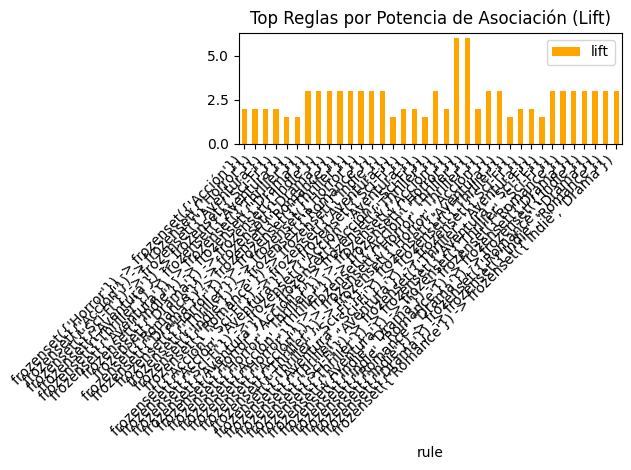

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
def lab_streaming_recommender():
    """
    Descubre asociaciones entre géneros cinematográficos.
    """
    # Simulación de sesiones de usuario
    sesiones = [
        ['Sci-Fi', 'Acción', 'Aventura'],
        ['Drama', 'Romance'],
        ['Sci-Fi', 'Acción'],
        ['Horror', 'Thriller', 'Acción'],
        ['Drama', 'Indie', 'Romance'],
        ['Sci-Fi', 'Aventura', 'Thriller']
    ]

    te = TransactionEncoder()
    df = pd.DataFrame(te.fit(sesiones).transform(sesiones), columns=te.columns_)

    # Buscamos asociaciones fuertes (Soporte bajo, pero Lift muy alto)
    items_frecuentes = apriori(df, min_support=0.1, use_colnames=True)
    rules = association_rules(items_frecuentes, metric="lift", min_threshold=1.5)

    print("Patrones de Consumo de Streaming:")
    print(rules[['antecedents', 'consequents', 'support', 'lift']].sort_values(by='lift', ascending=False))

    # Gráfico de barras de las mejores reglas
    rules['rule'] = rules['antecedents'].astype(str) + " -> " + rules['consequents'].astype(str)
    rules.plot(kind='bar', x='rule', y='lift', color='orange')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top Reglas por Potencia de Asociación (Lift)')
    plt.tight_layout()
    plt.show()

lab_streaming_recommender()


**Conclusion**

Si descubrimos que \{Horror\} => \{Thriller\} tiene un Lift de 2.0, el sistema de recomendación puede generar una categoría dinámica llamada "Tensión Extrema". Aplicación: Esto mejora el User Engagement y reduce la tasa de abandono (Churn Rate), ya que el usuario encuentra contenido relevante más rápido.

**Resumen:**

- Soporte: ¿Es común este patrón? (Evita casos aislados).
- Confianza: ¿Qué tan fiable es la predicción? (Precisión de la regla).
- Lift: ¿Es una relación real o coincidencia? (Valor estratégico).
